# Libraries

In [191]:
import os

os.chdir("..")

import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

# Load data

We are going to work only with 3 variables to start

In [238]:
train_df = pd.read_csv(
    "/Users/luisfernandocorcueraleon/Desktop/code/Credit-Score-Classification/data/train.csv"
)

train_sample_df = train_df[["Occupation", "Annual_Income", "Num_Credit_Inquiries"]]
target = train_df["Credit_Score"]

/var/folders/1f/54wv342x795c_zyzqlgyjjkw0000gn/T/ipykernel_60127/3808375836.py:1: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(


In [239]:
print(train_sample_df.shape)
display(train_sample_df.head())
display(target.head())
print(target.value_counts())

(100000, 3)


,Occupation,Annual_Income,Num_Credit_Inquiries
0,Scientist,19114.12,4.00
1,Scientist,19114.12,4.00
2,Scientist,19114.12,4.00
3,Scientist,19114.12,4.00
4,Scientist,19114.12,4.00


0    Good
1    Good
2    Good
3    Good
4    Good
Name: Credit_Score, dtype: str

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


**Objectives** 
1. Predict credit scoring
2. Classification problem
3. We'll reduce it into a binomial classification

# Check data

In [240]:
train_sample_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Occupation            100000 non-null  str    
 1   Annual_Income         100000 non-null  str    
 2   Num_Credit_Inquiries  98035 non-null   float64
dtypes: float64(1), str(2)
memory usage: 2.3 MB


In [241]:
train_sample_df["Occupation"].value_counts(normalize=True)

Occupation
_______         0.07
Lawyer          0.07
Architect       0.06
Engineer        0.06
Scientist       0.06
Mechanic        0.06
Accountant      0.06
Developer       0.06
Media_Manager   0.06
Teacher         0.06
Entrepreneur    0.06
Doctor          0.06
Journalist      0.06
Manager         0.06
Musician        0.06
Writer          0.06
Name: proportion, dtype: float64

In [242]:
train_sample_df["Annual_Income"].value_counts(normalize=True)

Annual_Income
17273.83     0.00
36585.12     0.00
20867.67     0.00
9141.63      0.00
17816.75     0.00
             ... 
41329.56_    0.00
10152115.0   0.00
38321.39_    0.00
16680.35_    0.00
37188.1_     0.00
Name: proportion, Length: 18940, dtype: float64

In [243]:
mask = train_sample_df["Annual_Income"].str.contains("_")
annual_income_check = train_sample_df[mask]
display(annual_income_check[mask].head())

annual_income_check["check_annual_income"] = annual_income_check[
    "Annual_Income"
].str.len() - annual_income_check["Annual_Income"].str.index("_")
annual_income_check["check_annual_income"].value_counts()

/var/folders/1f/54wv342x795c_zyzqlgyjjkw0000gn/T/ipykernel_60127/106685431.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display(annual_income_check[mask].head())


,Occupation,Annual_Income,Num_Credit_Inquiries
10,Teacher,34847.84_,2.00
27,Entrepreneur,30689.89_,4.00
32,Developer,35547.71_,4.00
56,Media_Manager,34081.38_,5.00
66,Doctor,114838.41_,3.00


check_annual_income
1    6980
Name: count, dtype: int64

In [244]:
train_sample_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Num_Credit_Inquiries,"98,035.00",27.75,193.18,0.00,3.00,6.00,9.00,"2,597.00"


In [245]:
train_sample_df["Num_Credit_Inquiries"].quantile(
    [0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.97, 0.98, 0.99]
)

0.01       0.00
0.05       0.00
0.25       3.00
0.50       6.00
0.75       9.00
0.90      12.00
0.95      13.00
0.97      15.00
0.98      16.00
0.99   1,109.28
Name: Num_Credit_Inquiries, dtype: float64

# Clean data

In [246]:
train_sample_df["target"] = target

### Annual Income

In [247]:
train_sample_df["Annual_Income_numeric"] = (
    train_sample_df["Annual_Income"].str.replace("_", "").astype("double")
)
train_sample_df.describe()

,Num_Credit_Inquiries,Annual_Income_numeric
count,"98,035.00","100,000.00"
mean,27.75,"176,415.70"
std,193.18,"1,429,618.05"
min,0.00,"7,005.93"
25%,3.00,"19,457.50"
50%,6.00,"37,578.61"
75%,9.00,"72,790.92"
max,"2,597.00","24,198,062.00"


In [248]:
train_sample_df["Annual_Income_numeric"].quantile(
    [0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.97, 0.98, 0.99]
)

0.01     7,536.00
0.05     9,743.51
0.25    19,457.50
0.50    37,578.61
0.75    72,790.92
0.90   113,085.87
0.95   134,533.32
0.97   149,616.12
0.98   166,837.64
0.99   179,987.28
Name: Annual_Income_numeric, dtype: float64

In [249]:
q1 = train_sample_df["Annual_Income_numeric"].quantile(0.25)
q3 = train_sample_df["Annual_Income_numeric"].quantile(0.75)

irq = q3 - q1

lower = q1 - 1.5 * irq
upper = q3 + 1.5 * irq

print(lower, upper)

-60542.630000000005 152791.05


In [250]:
income_mask = (train_sample_df["Annual_Income_numeric"] < lower) | (
    train_sample_df["Annual_Income_numeric"] > upper
)
print(f"numer of outliers: {mask.sum()}", f"\n% of outliers : {mask.mean()}")

numer of outliers: 6980 
% of outliers : 0.0698


In [251]:
train_sample_df["Annual_Income_numeric"] = train_sample_df[
    "Annual_Income_numeric"
].clip(lower=lower, upper=upper)

In [252]:
train_sample_df.describe()

,Num_Credit_Inquiries,Annual_Income_numeric
count,"98,035.00","100,000.00"
mean,27.75,"51,253.26"
std,193.18,"38,684.91"
min,0.00,"7,005.93"
25%,3.00,"19,457.50"
50%,6.00,"37,578.61"
75%,9.00,"72,790.92"
max,"2,597.00","152,791.05"


### Num_Credit_Inquiries

In [253]:
n_sum_values = train_sample_df["Num_Credit_Inquiries"].isnull().sum()
n_avg_values = train_sample_df["Num_Credit_Inquiries"].isnull().mean()
print(
    f"Number of null values in Num_Credit_Inquiries: {n_sum_values}\n"
    f"% of null values: {n_avg_values}"
)

Number of null values in Num_Credit_Inquiries: 1965
% of null values: 0.01965


In [254]:
avg_credit_inquires = train_sample_df["Num_Credit_Inquiries"].mean()
train_sample_df["Num_Credit_Inquiries"] = train_sample_df[
    "Num_Credit_Inquiries"
].fillna(avg_credit_inquires)

In [255]:
n_sum_values = train_sample_df["Num_Credit_Inquiries"].isnull().sum()
n_avg_values = train_sample_df["Num_Credit_Inquiries"].isnull().mean()
print(
    f"Number of null values in Num_Credit_Inquiries: {n_sum_values}\n"
    f"% of null values: {n_avg_values}"
)

Number of null values in Num_Credit_Inquiries: 0
% of null values: 0.0


In [256]:
train_sample_df.describe()

,Num_Credit_Inquiries,Annual_Income_numeric
count,"100,000.00","100,000.00"
mean,27.75,"51,253.26"
std,191.27,"38,684.91"
min,0.00,"7,005.93"
25%,3.00,"19,457.50"
50%,6.00,"37,578.61"
75%,9.00,"72,790.92"
max,"2,597.00","152,791.05"


In [257]:
p25 = train_sample_df["Num_Credit_Inquiries"].quantile(0.25)
p75 = train_sample_df["Num_Credit_Inquiries"].quantile(0.75)

irq = p75 - p25

lower = p25 - irq * 1.5
upper = p75 + irq * 1.5

print(lower, upper)

-6.0 18.0


In [258]:
train_sample_df["Num_Credit_Inquiries"] = train_sample_df["Num_Credit_Inquiries"].clip(
    upper=upper
)

In [259]:
mask = train_sample_df["Num_Credit_Inquiries"] < 0
train_sample_df = train_sample_df[~mask]

### Credit Scoring

In [ ]:
train_sample_df["target"].value_counts()

target
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

In [ ]:
.value_counts().unique()

<StringArray>
['Good', 'Standard', 'Poor']
Length: 3, dtype: str

In [270]:
train_sample_df["target"] = train_sample_df["target"].replace({"Standard": "Good"})
train_sample_df["target"].value_counts(normalize=True)

target
Good   0.71
Poor   0.29
Name: proportion, dtype: float64

In [271]:
df_cleaned = train_sample_df.drop(columns="Annual_Income")

In [272]:
df_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
Num_Credit_Inquiries,"100,000.00",6.22,4.42,0.00,3.00,6.00,9.00,18.00
Annual_Income_numeric,"100,000.00","51,253.26","38,684.91","7,005.93","19,457.50","37,578.61","72,790.92","152,791.05"


# Visualazing features

In [273]:
df_cleaned.dtypes

Occupation                   str
Num_Credit_Inquiries     float64
target                       str
Annual_Income_numeric    float64
dtype: object

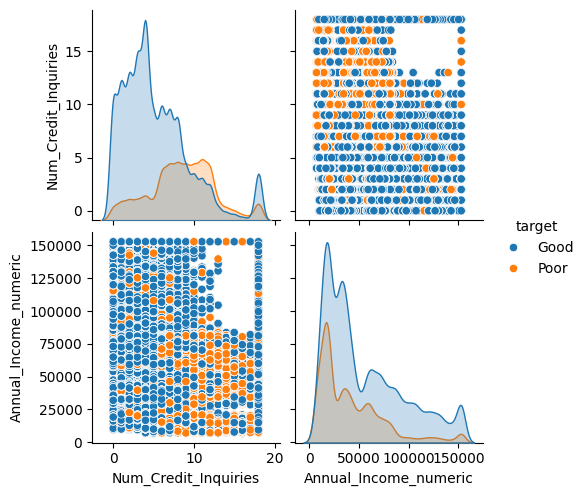

In [275]:
import seaborn as sns
import matplotlib

# n_samples_toplot = 10000
_ = sns.pairplot(df_cleaned, hue="target")

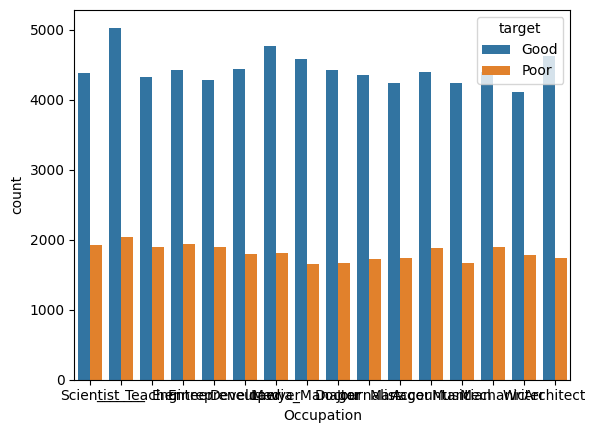

In [ ]:
_ = sns.countplot(
    data=df_cleaned,
    x="Occupation",
    hue="target",
)

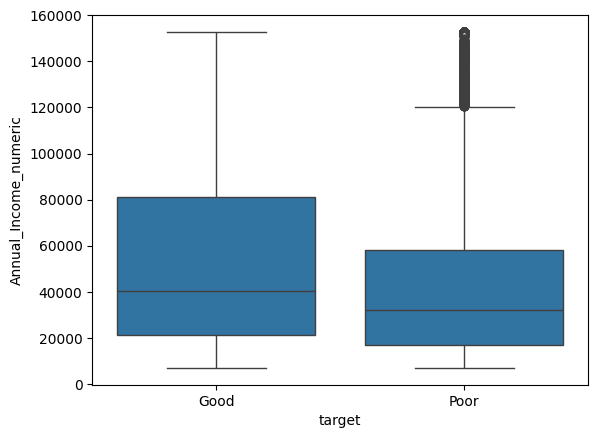

In [279]:
_ = sns.boxplot(data=df_cleaned, x="target", y="Annual_Income_numeric")

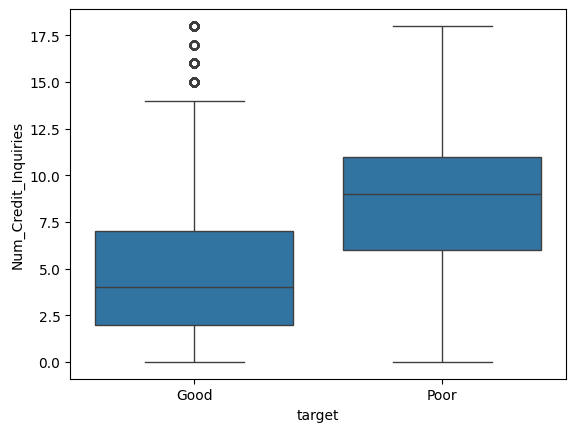

In [280]:
_ = sns.boxplot(data=df_cleaned, x="target", y="Num_Credit_Inquiries")

In [292]:
df_cleaned["Occupation"].unique()

<StringArray>
[    'Scientist',       '_______',       'Teacher',      'Engineer',
  'Entrepreneur',     'Developer',        'Lawyer', 'Media_Manager',
        'Doctor',    'Journalist',       'Manager',    'Accountant',
      'Musician',      'Mechanic',        'Writer',     'Architect']
Length: 16, dtype: str

In [293]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["Occupation"], drop_first=True)

In [296]:
df_cleaned.head()

,Num_Credit_Inquiries,target,Annual_Income_numeric,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Occupation________
0,4.00,Good,"19,114.12",False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,4.00,Good,"19,114.12",False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,4.00,Good,"19,114.12",False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,4.00,Good,"19,114.12",False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,4.00,Good,"19,114.12",False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


# Fast modelling

In [303]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

y = df_cleaned["target"]
X = df_cleaned.drop(columns="target")

In [309]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(75000, 17)
(25000, 17)
(75000,)
(25000,)


In [311]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
acc_train = lr.score(X_train, y_train)
print(f"accuracy in train: {acc_train}")

accuracy in train: 0.7121733333333333


In [317]:
y_proba

array([[0.52488778, 0.47511222],
       [0.76754274, 0.23245726],
       [0.71507869, 0.28492131],
       ...,
       [0.62816096, 0.37183904],
       [0.7118077 , 0.2881923 ],
       [0.78052804, 0.21947196]], shape=(25000, 2))

In [322]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    RocCurveDisplay,
    roc_auc_score,
    precision_recall_curve,
)

y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        Good       0.74      0.92      0.82     17756
        Poor       0.51      0.20      0.28      7244

    accuracy                           0.71     25000
   macro avg       0.62      0.56      0.55     25000
weighted avg       0.67      0.71      0.66     25000

[[16375  1381]
 [ 5831  1413]]


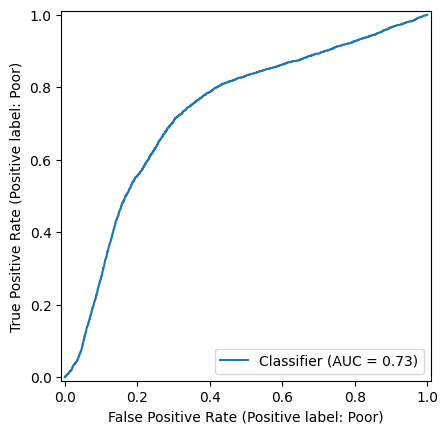

In [321]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba, pos_label="Poor")

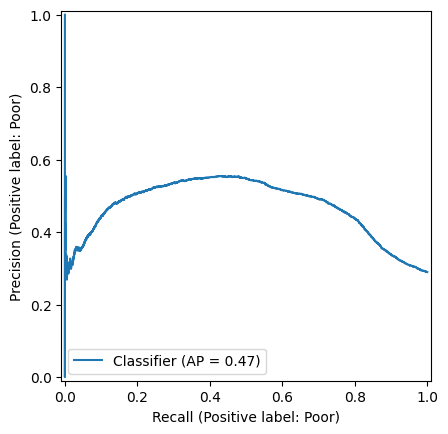

In [327]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba, pos_label="Poor")

In [326]:
from sklearn.metrics import average_precision_score

ap = average_precision_score((y_test == "Poor").astype(int), y_proba)

print(ap)

0.4675745810460255
